### Only to be used locally, venv works properly there

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import beastform4r as bfm

In [2]:
n_leaves = 30
birth_rate = 2.0
death_rate = 0.5

tree = bfm.Tree(n_leaves=n_leaves, method='yule',
            birth_rate=birth_rate)

independent = tree.generate_independent_data(
    n_sites=30,
    gain_rate=0.04,
    loss_rate=0.06,
    ascertain=True)

dependent = tree.generate_dependent_data(
    n_indep_sites=30,
    tiers=2,
    gain_rate=0.04,
    loss_rate=0.06,
    site_dep_prob=0.7,
    site_dep_mean=10,
    ascertain=True
)

print(dependent.head())

# write_xml_file("templates/template_yule.xml", independent, "yulei_test")

# # Dataset B: weakly dependent sites
# dependent = generate_dependent_dataset(
#     tree, languages,
#     n_blocks=60,
#     block_size=5
# )
# dependent = ascertain(dependent)

print("Independent dataset shape:", independent.shape)
# print("Dependent dataset shape:", dependent.shape)

print("\nIndependent (head):")
print(independent.head())

# print("\nDependent (head):")
# print(dependent.head())

Generated yule tree with 30 leaves.
       t16  t27  t28  t10  t4  t14  t15  t5  t17  t29  ...  t3  t12  t18  t19  \
cog_0    1    1    1    1   1    1    1   1    1    1  ...   1    1    1    1   
cog_1    1    1    1    1   0    1    1   1    1    1  ...   1    1    1    1   
cog_3    0    0    0    0   1    0    0   0    0    0  ...   0    0    0    0   
cog_4    0    0    0    0   0    0    0   0    0    0  ...   0    0    0    0   
cog_5    1    1    1    1   1    1    1   1    1    1  ...   1    1    1    1   

       t1  t2  t11  t25  t26  t7  
cog_0   1   1    1    1    1   1  
cog_1   1   1    1    1    1   0  
cog_3   0   0    0    0    0   0  
cog_4   0   0    0    0    0   1  
cog_5   1   1    1    1    1   1  

[5 rows x 30 columns]
Independent dataset shape: (17, 30)

Independent (head):
        t16  t27  t28  t10  t4  t14  t15  t5  t17  t29  ...  t3  t12  t18  \
cog_4     1    1    1    1   1    1    1   1    1    1  ...   1    1    1   
cog_5     1    1    1    1   1   

In [4]:
(independent.to_numpy())[1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0])

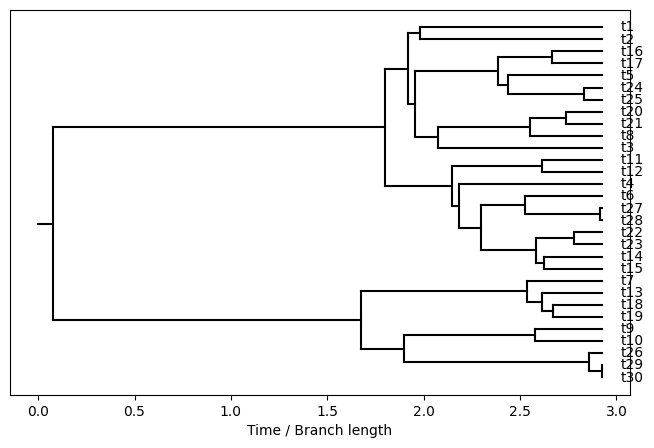

In [8]:
tree.plot()

In [9]:
independent['t2'].values, independent['t4'].values

print(sum(independent['t4'].values == independent['t3'].values)/len(independent['t1'].values))

0.8761609907120743


# Postprocessing Analysis

In [ ]:
rows = []
n_leaves = 30
for sites in [100, 200, 500, 1000, 2000]:
    for seed in [1, 2, 3, 4, 5]:
        prefix = f'run_sites{sites}_seed{seed}'
        dataset = pd.read_csv(f"{prefix}/{prefix}_tree_comparison_results.csv")
        
        for rf in dataset['RF']:
            rows.append({
                "sites": sites,
                "seed": seed,
                "RF": rf
            })

df_long = pd.DataFrame(rows)

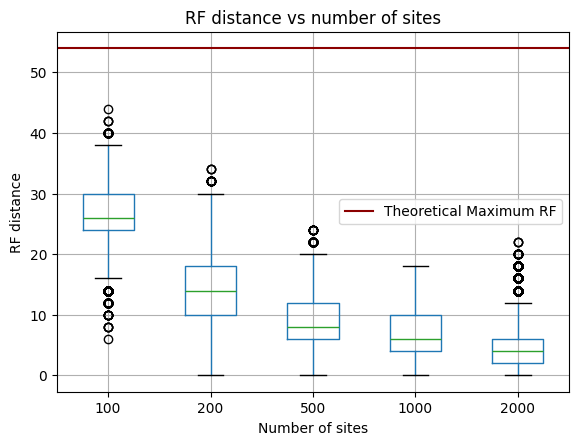

In [37]:
df_long.boxplot(column="RF", by="sites")
plt.axhline(2*n_leaves-6, color='darkred', label='Theoretical Maximum RF')
plt.title("RF distance vs number of sites")
plt.suptitle("")
plt.xlabel("Number of sites")
plt.ylabel("RF distance")
plt.legend()
plt.show()

In [38]:
df_long["nRF"] = df_long["RF"]/(2*30-6)
df_summary = df_long.groupby("sites")["nRF"].agg(["mean", "std"])
df_summary


,mean,std
sites,,
100,0.489984,0.089616
200,0.261850,0.100944
500,0.160619,0.077962
1000,0.120960,0.065253
2000,0.086780,0.075289
